# Group 2

# AI Interpretablity final tunings of best models

#Lime pipeline

In [1]:
categories = {
    0:"drink",      
    1:"food"  ,     
    2:"inside" ,     
    3:"menu"    ,     
    4:"outside",
}

In [2]:
# Define photos directory
#photos_dir='./yelp_photos/photos'
photos_dir=r"D:\loyalist\sem3\cnn\Yelp-Photos\yelp_photos\photos"

In [3]:
import pandas as pd
# Load the photos JSON file
#photos_df = pd.read_json("./yelp_photos/photos.json", lines=True)
photos_df = pd.read_json(r"D:\loyalist\sem3\cnn\Yelp-Photos\yelp_photos\photos.json", lines=True)
photos_df["img_path"] = photos_dir + '\\' + photos_df["photo_id"].astype(str) + ".jpg"

In [4]:
photos_df.head()

,photo_id,business_id,caption,label,img_path
0,zsvj7vloL4L5jhYyPIuVwg,Nk-SJhPlDBkAZvfsADtccA,Nice rock artwork everywhere and craploads of ...,inside,D:\loyalist\sem3\cnn\Yelp-Photos\yelp_photos\p...
1,HCUdRJHHm_e0OCTlZetGLg,yVZtL5MmrpiivyCIrVkGgA,,outside,D:\loyalist\sem3\cnn\Yelp-Photos\yelp_photos\p...
2,vkr8T0scuJmGVvN2HJelEA,_ab50qdWOk0DdB6XOrBitw,oyster shooter,drink,D:\loyalist\sem3\cnn\Yelp-Photos\yelp_photos\p...
3,pve7D6NUrafHW3EAORubyw,SZU9c8V2GuREDN5KgyHFJw,Shrimp scampi,food,D:\loyalist\sem3\cnn\Yelp-Photos\yelp_photos\p...
4,H52Er-uBg6rNrHcReWTD2w,Gzur0f0XMkrVxIwYJvOt2g,,food,D:\loyalist\sem3\cnn\Yelp-Photos\yelp_photos\p...


In [5]:
# Load the business JSON file
business_df = pd.read_json(r"D:\loyalist\sem3\cnn\Yelp-JSON\yelp_dataset\yelp_academic_dataset_business.json", lines=True)

In [6]:
#  Merge the two dataframes on 'business_id'
df = photos_df.merge(business_df, on="business_id", how="left")

In [7]:
# Selected metadata columns
selected_columns = [
    'photo_id', 'business_id', 'label', 'img_path',
    'stars', 'review_count', 'is_open',
    'latitude', 'longitude'
]
df = df[selected_columns].copy()

In [8]:
df.columns

Index(['photo_id', 'business_id', 'label', 'img_path', 'stars', 'review_count',
       'is_open', 'latitude', 'longitude'],
      dtype='object')

In [9]:
from sklearn.preprocessing import StandardScaler
def preprocess_metadata(df, scaler=None):
    meta_cols = ['stars', 'review_count', 'is_open', 'latitude', 'longitude']
    df_meta = df[meta_cols].copy()
    
    if scaler is None:
        scaler = StandardScaler()
        meta_scaled = scaler.fit_transform(df_meta)
    else:
        meta_scaled = scaler.transform(df_meta)
        
    # Convert scaled data back to a DataFrame with column names
    df_scaled = pd.DataFrame(meta_scaled, columns=[f"{col}_scaled" for col in meta_cols], index=df.index)
    
    return df_scaled, scaler

In [10]:
meta_scaled_df, scaler = preprocess_metadata(df)

In [11]:
df_merged = pd.concat([df, meta_scaled_df], axis=1)

In [12]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_preprocess
from lime import lime_image
from skimage.segmentation import mark_boundaries
from functools import partial

class Lime_Explainer:
    def __init__(self, model, model_type="vgg", metadata_dim=0):
        self.model = model
        self.model_type = model_type
        self.metadata_dim = metadata_dim
        self.lime_explainer = lime_image.LimeImageExplainer()

    def preprocess_image(self, img, target_size=(224, 224)):
        if img.dtype != np.uint8:
            img = img.astype(np.uint8)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, target_size)
        img = cv2.GaussianBlur(img, (5, 5), 0)
        img_yuv = cv2.cvtColor(img, cv2.COLOR_RGB2YUV)
        img_yuv[:, :, 0] = cv2.equalizeHist(img_yuv[:, :, 0])
        img = cv2.cvtColor(img_yuv, cv2.COLOR_YUV2RGB)
        img = np.clip(img, 30, 220).astype(np.float32)
        if self.model_type == 'vgg':
            return vgg_preprocess(img)
        elif self.model_type == 'effnet':
            return effnet_preprocess(img)
        return img

    def lime_predict(self, images, metadata=None):
        """Predict with metadata support for LIME."""
        processed_images = np.array([self.preprocess_image(img) for img in images])
        
        if self.model_type == 'vgg':
            return self.model.predict(processed_images)
        elif self.model_type == 'effnet':
            # Replicate metadata for each LIME sample
            if metadata is None:
                metadata = np.zeros((len(images), self.metadata_dim))
            elif metadata.shape[0] == 1:  # If single metadata provided
                metadata = np.tile(metadata, (len(images), 1))
            return self.model.predict([processed_images, metadata])

    def prediction(self, image_path, meta_data_row=None):
        """Predict class for a single image with optional metadata.
        
        Args:
            image_path: Path to image file
            meta_data_row: Optional metadata array (1D or 2D with shape (1, metadata_dim))
            
        Returns:
            Predicted class index
        """
        # Load image
        img = cv2.imread(image_path)
        if img is None:
            raise ValueError(f"Image at path '{image_path}' could not be read.")
        
        # Preprocess
        img = self.preprocess_image(img.astype(np.float32))  # shape: (224, 224, 3)
        
        # Add batch dimension
        img_batch = np.expand_dims(img, axis=0)  # shape: (1, 224, 224, 3)
        
        # Prepare metadata if using EfficientNet
        if self.model_type == 'effnet':
            if meta_data_row is None:
                meta_data_batch = np.zeros((1, self.metadata_dim))
            else:
                # Ensure metadata is 2D (batch_size, metadata_dim)
                meta_data_batch = np.array(meta_data_row).reshape(1, -1)
                if meta_data_batch.shape[1] != self.metadata_dim:
                    raise ValueError(f"Metadata dimension mismatch. Expected {self.metadata_dim}, got {meta_data_batch.shape[1]}")
        
        # Predict
        if self.model_type == 'vgg':
            y_pred_proba = self.model.predict(img_batch, verbose=0)
        elif self.model_type == 'effnet':
            y_pred_proba = self.model.predict([img_batch, meta_data_batch], verbose=0)
        
        # Get predicted class
        y_pred_class = np.argmax(y_pred_proba, axis=1)[0]
        
        print("Input shape to model:", img_batch.shape)
        if self.model_type == 'effnet':
            print("Metadata shape:", meta_data_batch.shape)
        print("Prediction Probabilities:", y_pred_proba)
        print("Predicted Class Index:", categories[y_pred_class])
        
        return y_pred_class
        

    def get_lime_explanation(self, img_path, metadata=None):
        original_img = cv2.imread(img_path)
        if original_img is None:
            raise ValueError(f"Image not found: {img_path}")
        
        image_array = img_to_array(original_img).astype(np.uint8)
        
        # Create metadata batch matching LIME's sample count
        if metadata is not None and len(metadata.shape) == 1:
            metadata = np.expand_dims(metadata, 0)
        
        # Bind metadata to the predictor
        predict_fn = partial(self.lime_predict, metadata=metadata)
        
        explanation = self.lime_explainer.explain_instance(
            image=image_array,
            classifier_fn=predict_fn,
            top_labels=5,
            hide_color=0,
            num_samples=1000  # Ensure this matches your needs
        )
        
        # Visualization code remains the same
        temp, mask = explanation.get_image_and_mask(
            label=explanation.top_labels[0],
            positive_only=True,
            hide_rest=False,
            num_features=5
        )
        plt.imshow(mark_boundaries(temp / 255.0, mask))
        plt.axis('off')
        plt.show()
        return explanation


In [13]:
random_img_data = df_merged.sample(1)
img_path = random_img_data.squeeze()['img_path']
scaled_columns = [col for col in df_merged.columns if col.endswith('_scaled')]
meta_data_row = random_img_data[scaled_columns].values.reshape(1, -1)  # as numpy array

In [14]:
img_path = "D:\\loyalist\\sem3\\cnn\\Yelp-Photos\\yelp_photos\\photos\\JPMUQocKWir1FWJFBJhhhQ.jpg"

### VGG model with unfreeze certain layers

In [15]:
from tensorflow.keras.models import load_model
vgg_transfer_learning_tuning1 = load_model(r"D:\loyalist\sem3\cnn\vgg_transfer_learning_final.h5")

In [16]:
vgg_transfer_learning_tuning1_lime = Lime_Explainer(vgg_transfer_learning_tuning1,"vgg")

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 

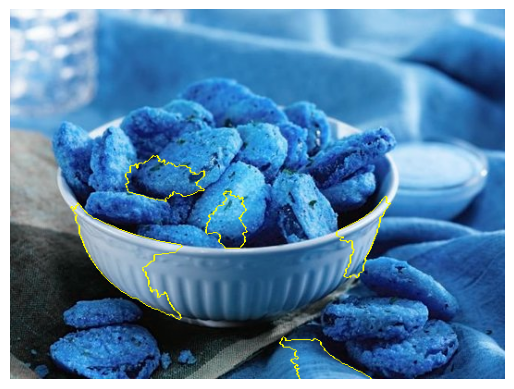

In [17]:
vgg_transfer_learning_tuning1_lime.get_lime_explanation(img_path)

In [18]:
vgg_transfer_learning_tuning1_lime.prediction(img_path)

Input shape to model: (1, 224, 224, 3)
Prediction Probabilities: [[8.1835398e-12 1.0000000e+00 2.1493626e-11 9.8923821e-12 8.2615880e-14]]
Predicted Class Index: food


1

### VGG model with train all layers from the start without freezing any part of the base model

In [19]:
from tensorflow.keras.models import load_model
vgg_transfer_learning_tuning2 = load_model(r"D:\loyalist\sem3\cnn\best_vgg16_model_without_freezing.h5")

In [20]:
vgg_transfer_learning_tuning2_lime = Lime_Explainer(vgg_transfer_learning_tuning2,"vgg")

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 

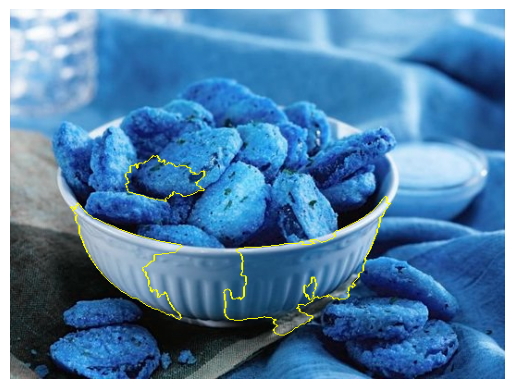

In [21]:
vgg_transfer_learning_tuning2_lime.get_lime_explanation(img_path)

In [22]:
vgg_transfer_learning_tuning2_lime.prediction(img_path)

Input shape to model: (1, 224, 224, 3)
Prediction Probabilities: [[0.06198522 0.05669589 0.14701083 0.7177358  0.01657223]]
Predicted Class Index: menu


3

In [23]:
from tensorflow.keras.models import load_model
efficientnet_finetuned = load_model(r"D:\loyalist\sem3\cnn\efficientnet_finetuned.h5")

In [24]:
efficientnet_finetuned_lime = Lime_Explainer(efficientnet_finetuned,"effnet", 5)

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

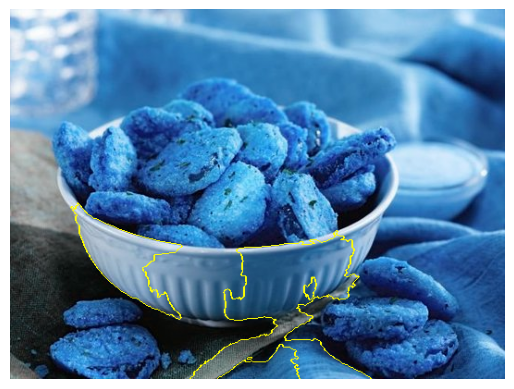

In [25]:
efficientnet_finetuned_lime.get_lime_explanation(img_path, meta_data_row)

In [26]:
efficientnet_finetuned_lime.prediction(img_path, meta_data_row)

Input shape to model: (1, 224, 224, 3)
Metadata shape: (1, 5)
Prediction Probabilities: [[2.6536794e-05 9.9996519e-01 7.6744482e-06 5.0359930e-08 6.1999248e-07]]
Predicted Class Index: food


1

In [27]:
img_path

'D:\\loyalist\\sem3\\cnn\\Yelp-Photos\\yelp_photos\\photos\\JPMUQocKWir1FWJFBJhhhQ.jpg'

# Project Summary: Image Interpretation using LIME

---

## Explainers Used
- **LIME (Local Interpretable Model-Agnostic Explanations):** Successfully used for interpreting model predictions.
- **SHAP:** Attempted but not successfully integrated for this task due to complexity and input handling issues.

---

## Steps in LIME Interpretation

### Step 1: Import Image and Business Data  
- Loaded image metadata from `photo.json`  
- Loaded associated business metadata from a separate JSON file

### Step 2: Create LIME Wrapper  
- Developed a wrapper class to handle:
  - Image loading and preprocessing
  - Metadata preprocessing (when applicable)
  - Running LIME explanations
  
This wrapper made it easier to plug in different models (VGG, EfficientNet) and visualize how they interpret input images.

---

## How to Interpret LIME Results

The LIME output highlights the specific regions of the image that influenced the model's prediction.

For example, for the image with ID `JPMUQocKWir1FWJFBJhhhQ`, which is a **bowl of cookies**:

- **VGG Model (with partially frozen layers):**
  - The yellow-highlighted patches in the LIME visualization suggest the model relied on **cookie texture** to infer it as food.
  
- **VGG Model (with all layers unfrozen):**
  - This version focused on the **edges of the bowl**, possibly mistaking it for a menu. It appears the model learned some high-level features but lacked specificity.

- **EfficientNet (with image + metadata):**
  - Still used similar image patches as the VGG model but produced more accurate predictions. This improvement may be due to the inclusion of **metadata** like review count, star ratings, and location, which helped the model disambiguate between food and non-food images.

---

## Key Learnings

- Learned that deep models don't rely on holistic shapes but rather **patches** or **textural segments** to make predictions.
- It was insightful to see how models "see" images—breaking them down into regions of interest (e.g., cookie texture or bowl edges) to form conclusions.
- Adding metadata enhanced interpretability and accuracy, particularly with EfficientNet.

---

## Challenges Faced

- Creating a universal LIME wrapper that could handle **different model architectures and input shapes** was non-trivial.
- Struggled with input dimensions—especially ensuring LIME received batched image arrays in the correct format.
- EfficientNet added complexity because it required **two inputs**: image and metadata. To handle this, I wrote a custom wrapper and also used suggestions from an LLM to structure the input pipeline correctly.

---

## Personal Reflection

This project gave me hands-on exposure to model interpretability and deepened my understanding of how neural networks focus on fine-grained details to make predictions. It also pushed me to think critically about model design, data preparation, and debugging multidimensional inputs—skills t

# LLM Prompt
starting LLM prompt = Deepseek, ChatGPT
    how to merge image and meta deta in Lime explain function.
ending LLM prompt = merge code from these function (gave effecive net and VGG processing methods)hat are crucial in real-world machine learning applications.
hat are crucial in real-world machine learning applications.


In [28]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.models import Model, load_model
from tqdm import tqdm

class ShapImageExplainer:
    def __init__(self, model, background_paths, target_size=(224, 224)):
        """
        Initialize SHAP explainer for food-related image classification
        
        Args:
            model: Pretrained Keras model
            background_paths: List of image paths for background samples
            target_size: Model input size (default 224x224 for VGG)
        """
        self.model = model
        self.target_size = target_size
        self.class_names = {
            0: "drink",
            1: "food", 
            2: "inside",
            3: "menu",
            4: "outside"
        }
        
        # Create model that outputs intermediate layer
        self.intermediate_model = Model(
            inputs=model.input,
            outputs=model.layers[7].output
        )
        
        # Load and preprocess background samples with progress bar
        print("Preprocessing background samples...")
        self.background = np.array([
            self._preprocess_image(p) 
            for p in tqdm(background_paths, desc="Loading background images")
        ])
        
        # Get intermediate features
        self.background_features = self._map_to_intermediate(self.background)
        
        # Initialize SHAP explainer
        print("Initializing SHAP explainer...")
        self.explainer = shap.GradientExplainer(
            (self.model.layers[7].input, self.model.output),
            self.background_features,
            local_smoothing=100
        )

    def _preprocess_image(self, img_path):
        """Preprocess single image with VGG16 preprocessing"""
        img = load_img(img_path, target_size=self.target_size)
        img_array = img_to_array(img)
        return vgg_preprocess(img_array.copy())

    def _map_to_intermediate(self, x):
        """Map input to intermediate layer outputs"""
        return self.intermediate_model.predict(x, verbose=0)

    def explain(self, img_path, top_classes=3):
        """
        Generate SHAP explanation for an image
        
        Args:
            img_path: Path to image to explain
            top_classes: Number of top classes to show
            
        Returns:
            Tuple of (shap_values, indexes)
        """
        try:
            # Preprocess image
            img = self._preprocess_image(img_path)
            img_batch = np.expand_dims(img, axis=0)
            
            # Get model predictions
            preds = self.model.predict(img_batch, verbose=0)[0]
            top_preds = preds.argsort()[-top_classes:][::-1]
            
            print(f"\nImage: {img_path}")
            print("Top Predictions:")
            for i, class_idx in enumerate(top_preds):
                print(f"{i+1}. {self.class_names[class_idx]}: {preds[class_idx]:.4f}")
            
            # Get SHAP values
            features = self._map_to_intermediate(vgg_preprocess(img_batch.copy()))
            shap_values, indexes = self.explainer.shap_values(
                features,
                ranked_outputs=top_classes
            )
            print(shap_values,indexes)
            # Create visualization
            plt.figure(figsize=(12, 4))
            shap.image_plot(
                shap_values,
                img_batch,
                labels=[[self.class_names[i] for i in indexes[0]]],
                show=False
            )
            plt.title(f"SHAP Explanation - {img_path.split('/')[-1]}")
            plt.tight_layout()
            plt.show()
            
            return shap_values, indexes
            
        except Exception as e:
            print(f"Explanation failed for {img_path}: {str(e)}")
            return None, None


img_paths = photos_df.sample(15)['img_path'].tolist()
    
# Load your pretrained model
print("Loading model...")
    
# Initialize explainer with first 50 images as background
background_paths = photos_df.sample(15)['img_path'].tolist()
explainer = ShapImageExplainer(model, background_paths)
    
# Generate explanations for each image
print("\nGenerating explanations...")
all_results = []
for img_path in tqdm(img_paths, desc="Explaining images"):
    result = explainer.explain(img_path, top_classes=3)
    if result:
        shap_values, indexes = result
        all_results.append({
                'image_path': img_path,
                'shap_values': shap_values,
                'top_classes': [explainer.class_names[i] for i in indexes[0]]
        })
    

Loading model...


NameError: name 'model' is not defined